# 🟠 TP5 | Projeto de Bloco: Inteligência Artificial e Machine Learning

Objetivos:

* Aplicar LDA para identificar e modelar tópicos em grandes conjuntos de texto;
* Avaliar e interpretar o desempenho de modelos de classificação, utilizando métricas apropriadas;
* Utilizar t-SNE para reduzir a dimensionalidade dos dados textuais e facilitar a visualização dos agrupamentos de tópicos;
* Empregar técnicas de explicabilidade (LIME, SHAP, force-plot) para revelar a importância das features em modelos de classificação black-box.

Base de dados: [Fake.BR - Corpus](https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv)

## ⤵️ Imports

In [ ]:
!pip install gensim nltk shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.7 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from nltk.tokenize import word_tokenize
from sklearn.pipeline import Pipeline
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.manifold import TSNE
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
import shap

In [ ]:
raw_data = pd.read_csv('https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv')

In [ ]:
raw_data.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


***

## ✴️ Criação das features

#### 📍 Computar o Term Frequency-Inverse Document Frequency (TF-IDF) para representar a importância das palavras em um conjunto de documentos.

In [ ]:
nltk.download('punkt')
nltk.download('tab_punkt')
nltk.download('stopwords')
stopwords_pt = stopwords.words('portuguese')

X = (
    raw_data['preprocessed_news']
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Error loading tab_punkt: Package 'tab_punkt' not found in
[nltk_data]     index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


***

## 🤖 Modelagem de Tópicos com LDA

#### 📍 Aplicar o algoritmo LDA para identificar tópicos prevalentes nos dados. A seleção do número de tópicos será baseada em métricas de coerência para garantir a relevância e a distinção entre os tópicos identificados.

In [ ]:
tokenized_data = [doc.split() for doc in X]
dictionary = Dictionary(tokenized_data)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_data]

coherence_scores = []

for n_topics in range(2, 11):
  lda_model = LdaModel(
      corpus=corpus,
      id2word=dictionary,
      num_topics=n_topics,
      random_state=42
  )

  coherence_model = CoherenceModel(
      model=lda_model,
      texts=tokenized_data,
      dictionary=dictionary,
      coherence='c_v'
  )

  coherence = coherence_model.get_coherence()

  coherence_scores.append({
      'n_topics': n_topics,
      'coherence': coherence
  })

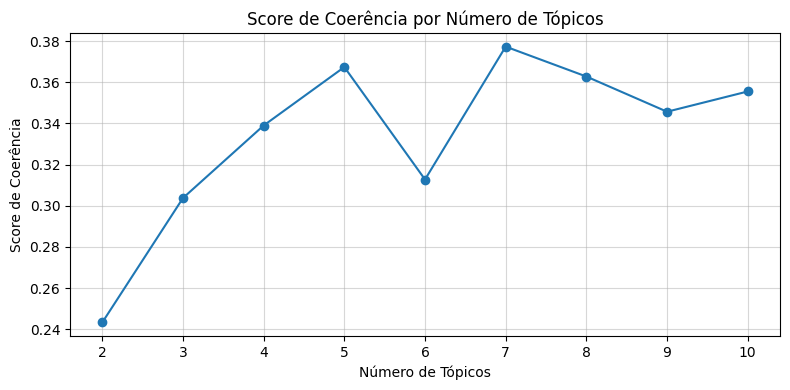

In [ ]:
df_coherence = pd.DataFrame(coherence_scores)

plt.figure(figsize=(8, 4))
plt.plot(
    df_coherence['n_topics'],
    df_coherence['coherence'],
    marker='o'
)

plt.xlabel('Número de Tópicos')
plt.ylabel('Score de Coerência')
plt.title('Score de Coerência por Número de Tópicos')
plt.xticks(range(2, 11))

plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
best_n_topics = df_coherence.loc[df_coherence['coherence'].idxmax()]['n_topics']
best_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=int(best_n_topics),
    random_state=42
)

print(f'Melhor número de tópicos (baseado na coerência): {int(best_n_topics)}')
print('\nTópicos encontrados:')
for idx, topic in best_lda_model.print_topics(num_words=10):
    print(f'Tópico {idx}: {topic}')

Melhor número de tópicos (baseado na coerência): 7

Tópicos encontrados:
Tópico 0: 0.016*"nao" + 0.006*"pais" + 0.005*"coreia" + 0.005*"norte" + 0.005*"sobre" + 0.005*"sao" + 0.005*"ser" + 0.004*"tambem" + 0.004*"trump" + 0.004*"ha"
Tópico 1: 0.014*"nao" + 0.006*"anos" + 0.006*"r" + 0.005*"sao" + 0.004*"ate" + 0.004*"tambem" + 0.004*"brasil" + 0.004*"ano" + 0.004*"ser" + 0.003*"mil"
Tópico 2: 0.014*"lula" + 0.006*"defesa" + 0.005*"triplex" + 0.005*"nao" + 0.005*"gebran" + 0.005*"processo" + 0.005*"jato" + 0.005*"lava" + 0.005*"desembargador" + 0.004*"delcidio"
Tópico 3: 0.015*"nao" + 0.012*"presidente" + 0.007*"governo" + 0.006*"temer" + 0.004*"dilma" + 0.004*"sobre" + 0.004*"disse" + 0.004*"ja" + 0.004*"r" + 0.004*"camara"
Tópico 4: 0.020*"nao" + 0.007*"lula" + 0.006*"federal" + 0.006*"ser" + 0.005*"sao" + 0.005*"presidente" + 0.005*"tambem" + 0.004*"temer" + 0.004*"sobre" + 0.004*"disse"
Tópico 5: 0.011*"nao" + 0.007*"milhoes" + 0.007*"r" + 0.005*"disse" + 0.005*"tambem" + 0.005*"ano

🗣️ O número ideal de tópicos foi definido utilizando a métrica de coerência (c_v). Foram avaliados modelos LDA com 2 a 10 tópicos, sendo que o maior score de coerência foi obtido com 7 tópicos (0,38). Esse resultado sugere que essa configuração produz tópicos mais semanticamente consistentes e interpretáveis.

***

## ⏳ Classificação de Textos

#### 📍 Desenvolver modelos de classificação para categorizar os textos com base nos tópicos identificados. Você pode escolher qualquer modelo aprendido ao longo do curso e deve escolher o melhor modelo usando as técnicas aprendidas, como busca de hiperparâmetros e validação cruzada

## ☑️ Avaliação de Desempenho

#### 📍 O desempenho dos modelos de classificação será avaliado utilizando métricas como precisão, recall, F1-score e AUC-ROC.

In [ ]:
doc_topics_full = [best_lda_model.get_document_topics(doc) for doc in corpus]

dominant_topics_full = []
for doc_topic_list in doc_topics_full:
    if not doc_topic_list:
      dominant_topics_full.append(-1)
    else:
      dominant_topic_id = max(doc_topic_list, key=lambda item: item[1])[0]
      dominant_topics_full.append(dominant_topic_id)

y = pd.Series(dominant_topics_full, name='dominant_topic')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

vectorizer = CountVectorizer(
    stop_words=stopwords_pt,
    max_features=2000,
).fit(X_train)

X_train_count = vectorizer.transform(X_train)
X_test_count = vectorizer.transform(X_test)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Random Forest
rf_classifier = RandomForestClassifier(random_state=42)

rf_param_grid = {
  'n_estimators': [100, 200, 300],
  'max_depth': [5,10, 15]
}

rf_grid_search = GridSearchCV(
  rf_classifier,
  rf_param_grid,
  cv=5,
  n_jobs=-1,
  return_train_score=True,
  refit='accuracy',
  scoring=['accuracy', 'f1', 'precision','recall', 'roc_auc']
)

rf_grid_search.fit(X_train_count, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [100, 200, 300]},
             refit='accuracy', return_train_score=True,
             scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc'])

In [ ]:
best_rf_model = rf_grid_search.best_estimator_

rf_accuracy_mean_cv = rf_grid_search.cv_results_['mean_test_accuracy'][rf_grid_search.best_index_]
rf_std_accuracy_cv = rf_grid_search.cv_results_['std_test_accuracy'][rf_grid_search.best_index_]

rf_predictions = best_rf_model.predict(X_test_count)
rf_precision_test = precision_score(y_test, rf_predictions, average='weighted')
rf_recall_test = recall_score(y_test, rf_predictions, average='weighted')

metrics_data = {
  'Model': ['Random Forest'],
  'Accuracy (CV Mean)': [rf_accuracy_mean_cv],
  'Precision (Test Set)': [rf_precision_test],
  'Recall (Test Set)': [rf_recall_test],
  'F1-Score (Test Set)': [2 * (rf_precision_test * rf_recall_test) / (rf_precision_test + rf_recall_test)],
  'Std Accuracy (CV)': [rf_std_accuracy_cv]
}

df_metrics = pd.DataFrame(metrics_data)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best Random Forest:
RandomForestClassifier(max_depth=15, n_estimators=300, random_state=42)

F1-Score for Random Forest:
0.663



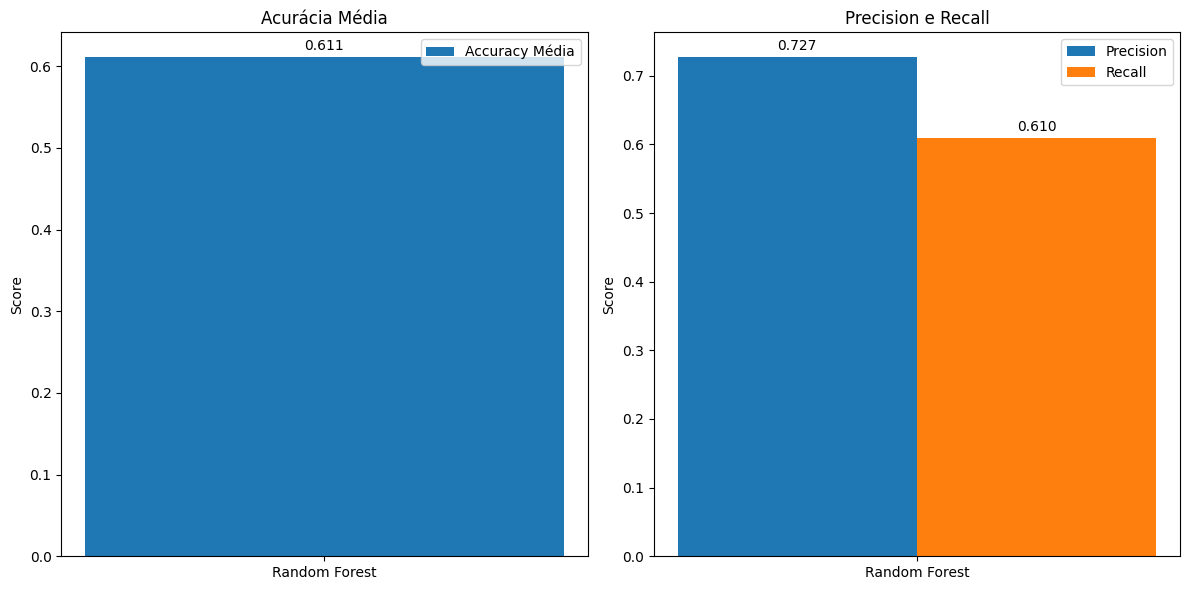

In [ ]:
print(f'Best Random Forest:\n{best_rf_model}\n')
print(f"F1-Score for Random Forest:\n{metrics_data['F1-Score (Test Set)'][0]:.3f}\n")

plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Accuracy e Std
x = np.arange(len(df_metrics))

plt.subplot(1, 2, 1)
bars1 = plt.bar(
  df_metrics['Model'],
  df_metrics['Accuracy (CV Mean)'],
  width=0.4,
  label='Accuracy Média'
)

plt.bar_label(bars1, fmt='%.3f', padding=3)

plt.xticks(x)
plt.title('Acurácia Média')
plt.ylabel('Score')
plt.legend()

# Subplot 2: Precision e Recall
plt.subplot(1, 2, 2)

x = np.arange(len(df_metrics))
width = 0.35

bars1 = plt.bar(
  x - width/2,
  df_metrics['Precision (Test Set)'],
  width=width,
  label='Precision'
)

bars2 = plt.bar(
  x + width/2,
  df_metrics['Recall (Test Set)'],
  width=width,
  label='Recall'
)

plt.bar_label(bars1, fmt='%.3f', padding=3)
plt.bar_label(bars2, fmt='%.3f', padding=3)

plt.xticks(x, df_metrics['Model'])
plt.title('Precision e Recall')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

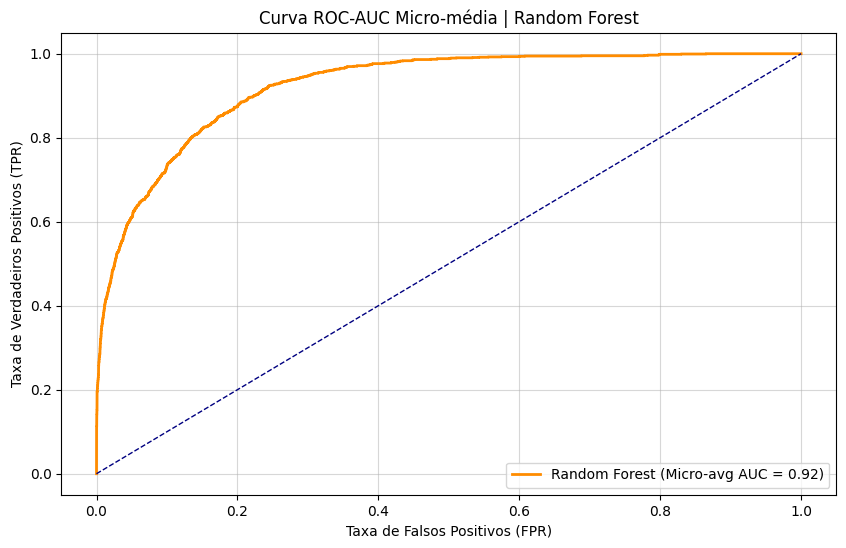

In [ ]:
plt.figure(figsize=(10, 6))

rf_predictions_proba_all_classes = best_rf_model.predict_proba(X_test_count)

n_classes = int(best_n_topics)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

fpr_micro, tpr_micro, _ = roc_curve(y_test_binarized.ravel(), rf_predictions_proba_all_classes.ravel())
auc_micro = roc_auc_score(y_test_binarized, rf_predictions_proba_all_classes, multi_class='ovr', average='micro')

plt.plot(fpr_micro, tpr_micro, label=f'Random Forest (Micro-avg AUC = {auc_micro:.2f})', color='darkorange', linewidth=2)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1)
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC-AUC Micro-média | Random Forest')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

***

## 📈 Visualização com t-SNE
#### 📍 Aplicar a técnica de t-SNE nos dados textuais vetorizados para reduzir a dimensionalidade e visualizar os agrupamentos de documentos de maneira intuitiva, facilitando a identificação de padrões e outliers.

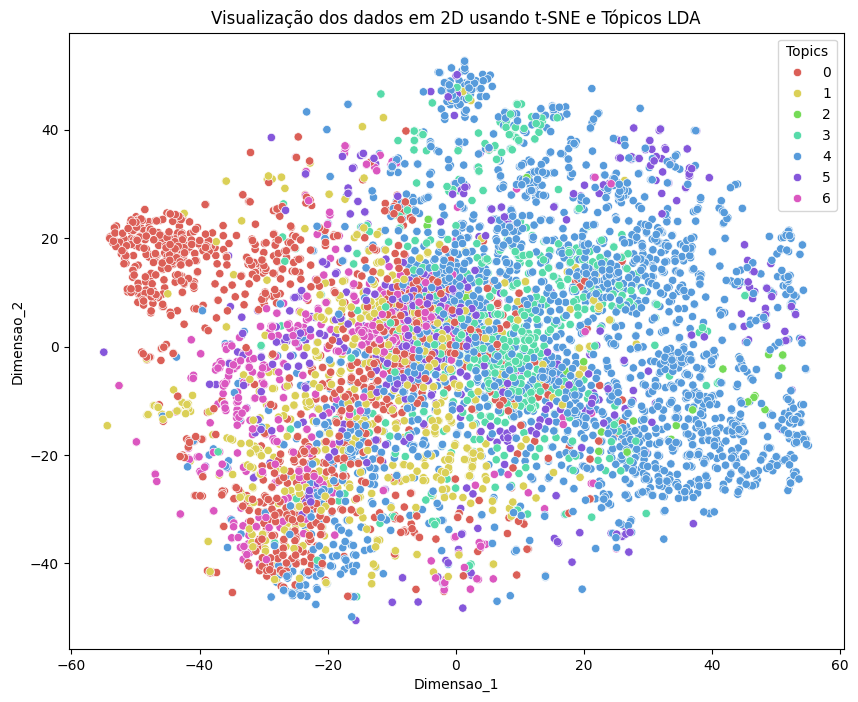

In [ ]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42, init='random', learning_rate='auto')
X_tsne = tsne.fit_transform(X_train_count)

df_tsne = pd.DataFrame(X_tsne, columns=['Dimensao_1', 'Dimensao_2'])

tokenized_X_train = [doc.split() for doc in X_train]
corpus_X_train = [dictionary.doc2bow(doc) for doc in tokenized_X_train]
doc_topics = [best_lda_model.get_document_topics(doc) for doc in corpus_X_train]

dominant_topics = []
for doc_topic_list in doc_topics:
    if not doc_topic_list:
        dominant_topics.append(-1)
    else:
        dominant_topic_id = max(doc_topic_list, key=lambda item: item[1])[0]
        dominant_topics.append(dominant_topic_id)

df_tsne['Topics'] = dominant_topics

plt.figure(figsize=(10, 8))
sns.scatterplot(
  x='Dimensao_1', y='Dimensao_2',
  hue='Topics',
  palette=sns.color_palette("hls", int(best_n_topics)),
  data=df_tsne,
  legend="full"
)
plt.title("Visualização dos dados em 2D usando t-SNE e Tópicos LDA")
plt.show()

***

## 🤔 Interpretação de Modelos com LIME, SHAP e Force-Plot

#### 📍 Utilizar SHAP para explicar as previsões individuais, identificando a contribuição de cada feature para a decisão do modelo. O force-plot será usado para visualizar essas contribuições de maneira agregada, oferecendo insights sobre a lógica de decisão do modelo.

Force plot para a primeira amostra do conjunto de teste:


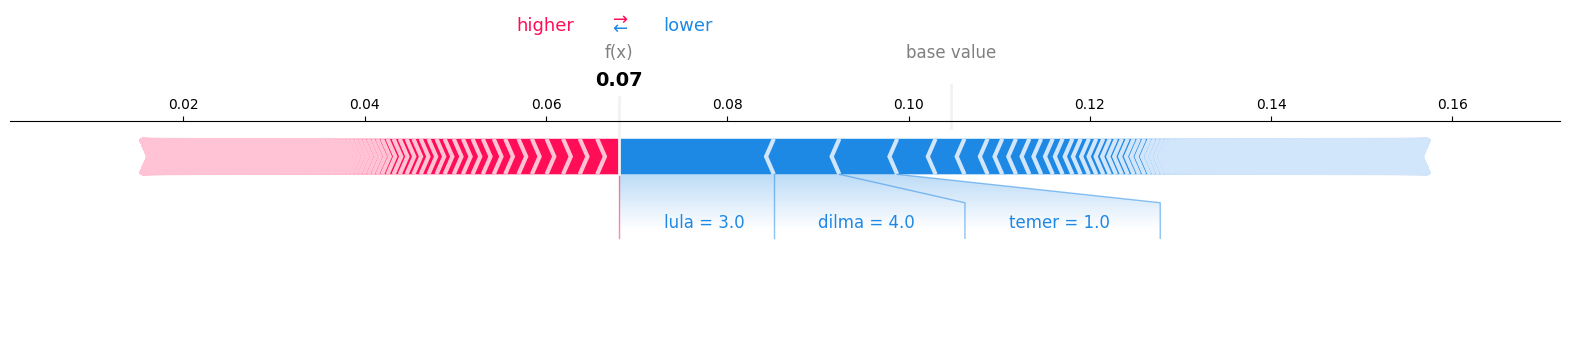

In [ ]:
shap.initjs()

X_test_sample_dense = X_test_count[:100].toarray()
X_test_sample_df = pd.DataFrame(X_test_sample_dense, columns=vectorizer.get_feature_names_out())

explainer = shap.TreeExplainer(best_rf_model)

shap_values = explainer.shap_values(X_test_sample_dense)

expected_value = explainer.expected_value[1]

print("Force plot para a primeira amostra do conjunto de teste:")
shap.force_plot(expected_value, shap_values[0, :, 1], X_test_sample_df.iloc[0], feature_names=vectorizer.get_feature_names_out(), matplotlib=True)


Summary plot para a importância geral das features:


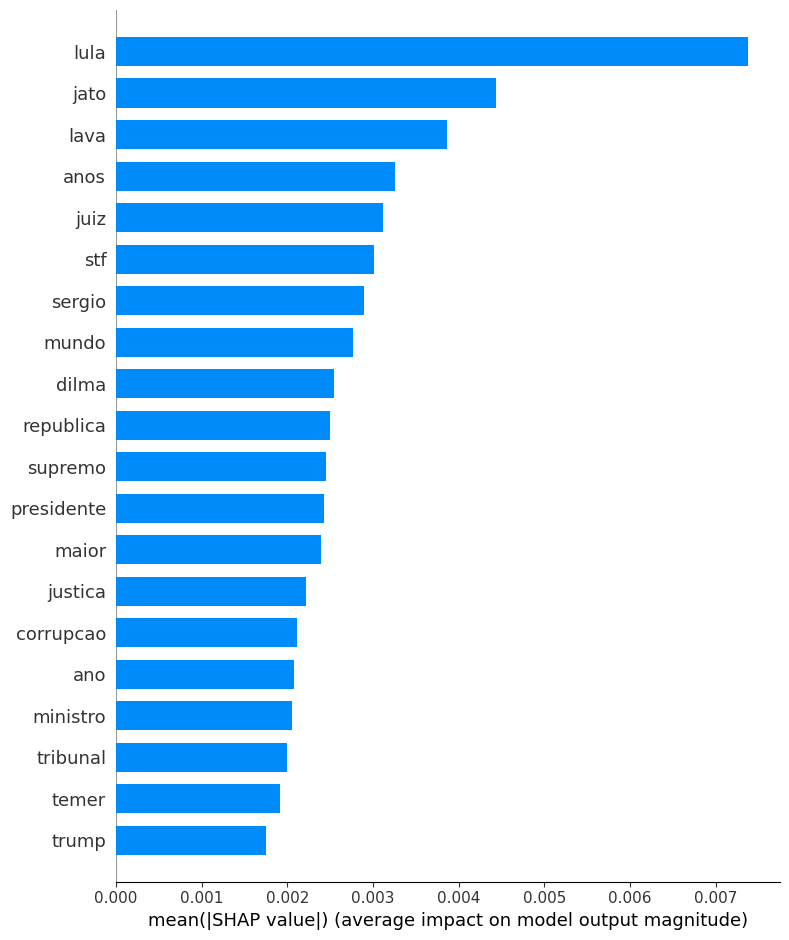

In [ ]:
print("\nSummary plot para a importância geral das features:")
shap.summary_plot(shap_values[:, :, 1], X_test_sample_df, feature_names=vectorizer.get_feature_names_out(), plot_type="bar")

***

## 📊 Análise dos resultados

#### 📍 Enumere as conclusões que podem ser tomadas a partir dos resultados obtidos.

🗣️ Com base nas análises que construí, pode-se concluir que:

**1. Número de tópicos (LDA)**

* A análise de coerência indicou que o modelo com **7 tópicos** apresentou o melhor desempenho semântico.
* Além disso, os tópicos extraídos comprovam a existência de grupos de palavras com diferentes contextos.

**2. Desempenho moderado na classificação com Random Forest**
* Após a otimização dos hiperparâmetros por validação cruzada, o modelo Random Forest alcançou 61,1% de acurácia, indicando uma capacidade moderada de classificação. Embora superior ao acaso, o resultado sugere que ainda existem dificuldades na separação das classes presentes no conjunto de dados.

**3. Precisão superior ao recall**
As métricas de precisão (72,7%) e recall (61,0%) mostram que o modelo é mais eficiente em evitar falsos positivos do que em identificar corretamente todos os exemplos positivos. Isso indica uma tendência mais conservadora nas previsões, priorizando decisões mais confiáveis em detrimento da cobertura total dos casos positivos.

**4. F1-Score confirma o equilíbrio limitado do modelo**
O F1-Score de 66,3% reflete o equilíbrio entre precisão e recall, confirmando um desempenho intermediário do classificador. Embora o modelo apresente resultados razoáveis, o valor obtido sugere que ainda há espaço para melhorias, seja por meio de ajustes adicionais de hiperparâmetros, engenharia de atributos ou utilização de modelos mais robustos.

**5. As métricas indicam consistência nos resultados**
A proximidade entre acurácia, recall e F1-Score demonstra que o modelo apresenta comportamento relativamente estável entre diferentes métricas de avaliação. No entanto, os valores obtidos indicam que sua capacidade de generalização ainda é limitada para aplicações que exijam alta precisão na identificação de notícias falsas.

**6. A curva ROC-AUC evidenciou um bom poder discriminativo**
* O valor elevado de AUC, 92%, mostra que o modelo separa eficientemente os tópicos, apresentando desempenho significativamente superior ao de um classificador aleatório.

**7. A visualização com t-SNE evidenciou sobreposição entre tópicos**
Embora alguns agrupamentos possam ser observados, a forte mistura de cores no espaço projetado indica que os tópicos gerados pelo LDA não formam grupos completamente separados. Isso sugere que os temas presentes nas notícias possuem relações semânticas entre si, compartilhando termos e contextos semelhantes ao longo do corpus.

**8. As técnicas de explicabilidade permitiram compreender os fatores que influenciaram as previsões**
* A análise com SHAP mostrou que determinadas palavras exerceram maior influência nas decisões do modelo, destacando-se termos como **"lula"**, **"jato"**, **"lava"**, **"anos"** e **"juiz"** entre as variáveis mais importantes. O gráfico de importância global evidenciou que esses termos tiveram maior impacto médio nas predições do Random Forest.
* Além disso, o gráfico *Force Plot* permitiu interpretar uma previsão individual, mostrando como palavras específicas contribuíram para aumentar ou reduzir a probabilidade prevista para determinada classe. Por exemplo, termos como **"lula"**, **"dilma"** e **"temer"** apresentaram influência relevante na decisão do modelo para a amostra analisada.
* Dessa forma, o uso do SHAP aumentou a transparência do processo de classificação, permitindo compreender não apenas o desempenho do modelo, mas também quais características textuais foram determinantes para suas previsões. Isso torna os resultados mais interpretáveis e confiáveis para análise e validação do modelo.